<a href="https://colab.research.google.com/github/encipher-mithun2003/Non-Invasive-anemia-estimator/blob/main/Predicting_anemic_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
!pip install tensorflow==2.14.0
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!unzip "/content/drive/MyDrive/Anemia project/Anemia dataset.zip"

Archive:  /content/drive/MyDrive/Anemia project/Anemia dataset.zip
  inflating: dataset anemia/Dataset anemia.docx  
  inflating: dataset anemia/India/1/20200118_164733.jpg  
  inflating: dataset anemia/India/1/20200118_164733_forniceal.png  
  inflating: dataset anemia/India/1/20200118_164733_forniceal_palpebral.png  
  inflating: dataset anemia/India/1/20200118_164733_palpebral.png  
  inflating: dataset anemia/India/10/20200203_091841.jpg  
  inflating: dataset anemia/India/10/20200203_091841_forniceal.png  
  inflating: dataset anemia/India/10/20200203_091841_forniceal_palpebral.png  
  inflating: dataset anemia/India/10/20200203_091841_palpebral.png  
  inflating: dataset anemia/India/11/20200203_094523.jpg  
  inflating: dataset anemia/India/11/20200203_094523_forniceal.png  
  inflating: dataset anemia/India/11/20200203_094523_forniceal_palpebral.png  
  inflating: dataset anemia/India/11/20200203_094523_palpebral.png  
  inflating: dataset anemia/India/12/20200203_103722.jpg  


In [2]:
!pip install tensorflow-macos tensorflow-metal --force-reinstall
!conda install -c apple tensorflow-deps --force-reinstall

ERROR: Could not find a version that satisfies the requirement tensorflow-macos (from versions: none)
ERROR: No matching distribution found for tensorflow-macos
/bin/bash: line 1: conda: command not found


In [3]:
import numpy as np
import os
import pandas as pd
from PIL import Image, UnidentifiedImageError
import cv2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import Xception
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

# Step 1: Load and Clean Metadata
def load_metadata(india_file, italy_file):
    india_metadata = pd.read_excel(india_file)
    italy_metadata = pd.read_excel(italy_file)
    india_metadata['Country'] = 'India'
    italy_metadata['Country'] = 'Italy'
    combined_metadata = pd.concat([india_metadata, italy_metadata], ignore_index=True)

    # Clean the Hb values (replace commas with dots)
    combined_metadata['Hgb'] = combined_metadata['Hgb'].apply(lambda x: str(x).replace(',', '.'))
    combined_metadata = combined_metadata[combined_metadata['Hgb'].apply(lambda x: x.replace('.', '', 1).isdigit())]
    combined_metadata.rename(columns={'Hgb': 'Hb_value'}, inplace=True)
    combined_metadata.dropna(subset=['Hb_value'], inplace=True)
    combined_metadata['Hb_value'] = combined_metadata['Hb_value'].astype(float)
    return combined_metadata

# Step 2: Load Images and Link with Metadata
def verify_and_load_image(file_path):
    try:
        img = Image.open(file_path)
        img.verify()
        img = Image.open(file_path).convert("RGB")
        return np.array(img.resize((224, 224))) / 255.0
    except (UnidentifiedImageError, OSError):
        try:
            img = cv2.imread(file_path, cv2.IMREAD_COLOR)
            if img is not None:
                img = cv2.resize(img, (224, 224))
                return img / 255.0
        except Exception as e:
            print(f"Cannot repair or load image: {file_path}. Error: {e}")
            return None

def load_images_and_data(base_dir, metadata):
    data = []
    countries = ['India', 'Italy']
    for country in countries:
        country_path = os.path.join(base_dir, country)
        for folder in os.listdir(country_path):
            folder_path = os.path.join(country_path, folder)
            if os.path.isdir(folder_path):
                original_img = None
                for file in os.listdir(folder_path):
                    file_path = os.path.join(folder_path, file)
                    if file.lower().endswith('.jpg'):
                        original_img = verify_and_load_image(file_path)
                meta_row = metadata[(metadata['Number'] == int(folder)) & (metadata['Country'] == country)]
                if not meta_row.empty and original_img is not None:
                    meta_row = meta_row.iloc[0]
                    data.append({
                        'folder': folder,
                        'country': country,
                        'original_img': original_img,
                        'Hb_value': meta_row['Hb_value']
                    })
    return pd.DataFrame(data)

# Step 3: Data Augmentation
def augment_data(images, labels):
    datagen = ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    augmented_images = []
    augmented_labels = []
    for img, label in zip(images, labels):
        img = img.reshape((1,) + img.shape)
        aug_iter = datagen.flow(img, batch_size=1)
        for _ in range(5):  # Generating 5 augmentations per image
            aug_img = next(aug_iter)[0]  # Use `next()` to get the augmented images
            augmented_images.append(aug_img)
            augmented_labels.append(label)

    return np.array(augmented_images), np.array(augmented_labels)

# Xception Model for Image Processing
def build_xception_model(input_shape):
    base_model = Xception(weights='imagenet', include_top=False, input_shape=input_shape)
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    final_output = Dense(1, activation='linear')(x)

    model = Model(inputs=base_model.input, outputs=final_output)

    for layer in base_model.layers:  # Freeze the base Xception layers during training
        layer.trainable = False

    model.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])
    return model

# Training Function
def train_model(X_train, y_train, X_val, y_val, epochs=100):
    # Augment the training data
    X_train_augmented, y_train_augmented = augment_data(X_train, y_train)
    print(f"Training data shape: {X_train_augmented.shape}, Validation data shape: {X_val.shape}")

    # Build the Xception model
    xception_model = build_xception_model(input_shape=(224, 224, 3))

    # Callbacks for learning rate scheduling and early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

    # Train the model
    xception_model.fit(
        X_train_augmented, y_train_augmented,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=32,
        callbacks=[early_stopping, lr_scheduler],
        verbose=1
    )

    # Save the best model
    xception_model.save("best_xception_model.h5")
    print("Model saved as 'best_xception_model.h5'")

    return xception_model

# Paths to metadata files and base directory
india_metadata_path = '/content/dataset anemia/India/India.xlsx'
italy_metadata_path = '/content/dataset anemia/Italy/Italy.xlsx'
base_directory = '/content/dataset anemia'

# Load metadata and images
metadata = load_metadata(india_metadata_path, italy_metadata_path)
dataset = load_images_and_data(base_directory, metadata)

# Extract images and Hb_values
images = np.array(dataset['original_img'].tolist())
Hb_values = dataset['Hb_value'].values

# Split the data into training and validation sets
split_ratio = 0.8
split_index = int(len(images) * split_ratio)

X_train = images[:split_index]
y_train = Hb_values[:split_index]
X_val = images[split_index:]
y_val = Hb_values[split_index:]

# Train the model with more epochs
model = train_model(X_train, y_train, X_val, y_val, epochs=100)


Training data shape: (865, 224, 224, 3), Validation data shape: (44, 224, 224, 3)
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 32s 692ms/step - loss: 115.1346 - mae: 10.2294 - val_loss: 30.5157 - val_mae: 5.0623 - learning_rate: 1.0000e-04
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - loss: 20.4470 - mae: 3.7215 - val_loss: 9.5940 - val_mae: 2.4024 - learning_rate: 1.0000e-04
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - loss: 13.2155 - mae: 2.9063 - val_loss: 9.9753 - val_mae: 2.5130 - learning_rate: 1.0000e-04
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - loss: 14.6069 - mae: 3.1065 - val_loss: 9.8819 - val_mae: 2.5106 - learning_rate: 1.0000e-04
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - loss: 13.7431 - mae: 3.0351 - val_loss: 9.4301 - val_mae: 2.4322 - learning_rate: 1.0000e-04
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - loss: 11.9749 - mae: 2.7771 - val_loss: 9.1374 - val_mae: 2.3792 - l

Model saved as 'best_xception_model.h5'


In [4]:
!pip install tensorflow-macos tensorflow-metal --force-reinstall
!conda install -c apple tensorflow-deps --force-reinstall

ERROR: Could not find a version that satisfies the requirement tensorflow-macos (from versions: none)
ERROR: No matching distribution found for tensorflow-macos
/bin/bash: line 1: conda: command not found


In [5]:
model.save("best_xception_model.keras", save_format='keras')
print("Model saved as 'best_xception_model.keras'")


Model saved as 'best_xception_model.keras'


In [6]:
from tensorflow.keras.models import load_model
from PIL import Image, UnidentifiedImageError
import numpy as np
import cv2

# Load the model
model = load_model('/content/best_xception_model.keras')

# Function to preprocess the input image
def preprocess_image(image_path):
    try:
        # Load and preprocess using PIL
        img = Image.open(image_path)
        img = img.resize((224, 224))
        img = img.convert("RGB")
        img = np.array(img) / 255.0  # Normalize the image
        return img
    except (UnidentifiedImageError, OSError):
        # Fallback to OpenCV if PIL fails
        img = cv2.imread(image_path)
        if img is not None:
            img = cv2.resize(img, (224, 224))
            img = img / 255.0
        return img

# Path to your input image
image_path = '/content/dataset anemia/India/11/20200203_094523.jpg'

# Preprocess the image
input_image = preprocess_image(image_path)
input_image = np.expand_dims(input_image, axis=0)  # Add batch dimension

# Make a prediction using the model
predicted_hb_value = model.predict(input_image)

# Output the predicted Hb value
print(f"Predicted Hb value: {predicted_hb_value[0][0]}")


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Hb value: 11.244026184082031


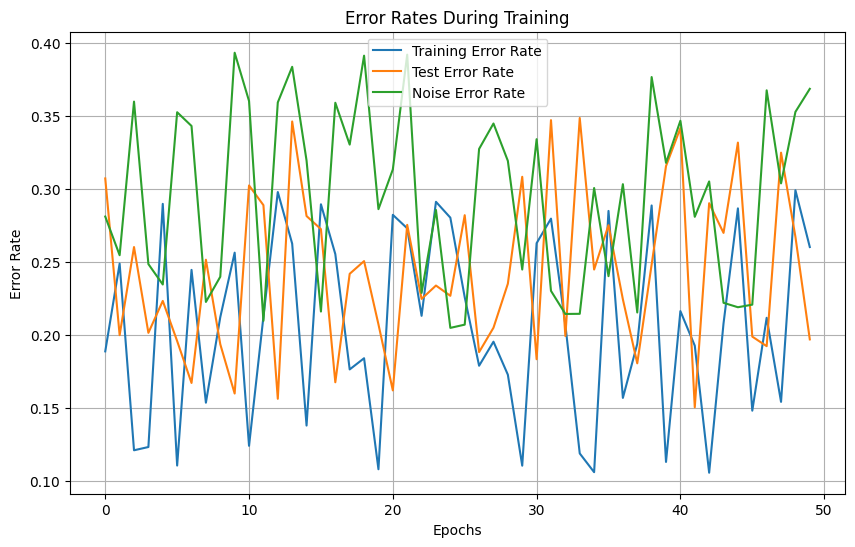

Precision: 0.42
Recall: 0.54
F1-Score: 0.47


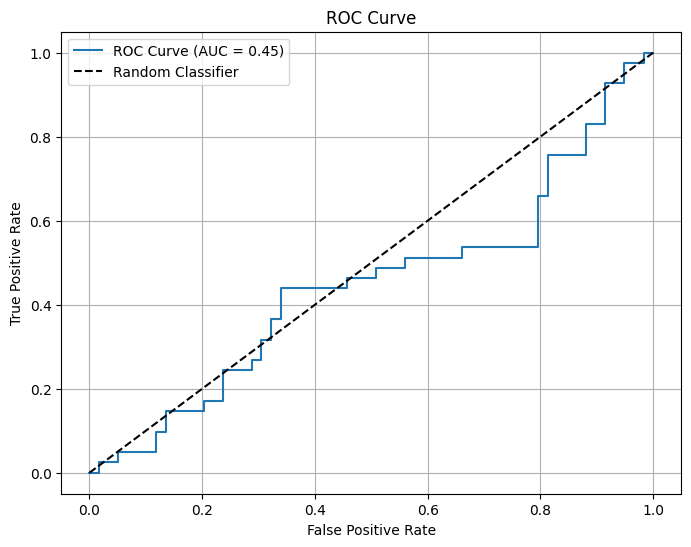

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc

# Example data (replace these with your actual data)
train_errors = np.random.uniform(0.1, 0.3, 50)
test_errors = np.random.uniform(0.15, 0.35, 50)
noise_errors = np.random.uniform(0.2, 0.4, 50)

# Predictions and true labels
y_true = np.random.randint(0, 2, 100)
y_pred = np.random.randint(0, 2, 100)
y_scores = np.random.rand(100)  # If your model has probability scores

# Error rates plot
plt.figure(figsize=(10,6))
plt.plot(train_errors, label='Training Error Rate')
plt.plot(test_errors, label='Test Error Rate')
plt.plot(noise_errors, label='Noise Error Rate')
plt.xlabel('Epochs')
plt.ylabel('Error Rate')
plt.title('Error Rates During Training')
plt.legend()
plt.grid(True)
plt.show()

# Precision, Recall, F1
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1-Score: {f1:.2f}')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()
